In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [3]:
print(sklearn.__version__)
print(pd.__version__)

1.7.2
2.3.0


In [4]:
df = pd.read_csv("TravelInsurancePrediction.csv",index_col=0)
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [5]:
df.size

17883

In [6]:
df.isnull().sum()

Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [7]:
df["AnnualIncome"].max()


np.int64(1800000)

In [8]:
df["Employment Type"].unique()
df["GraduateOrNot"].unique()
df["ChronicDiseases"].unique()

array([1, 0])

(array([813., 806., 145.]),
 array([ 500000., 1000000., 1500000., 1800000.]),
 <BarContainer object of 3 artists>)

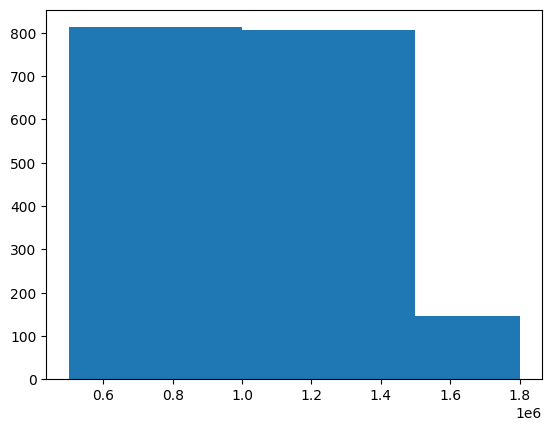

In [9]:
plt.hist(df["AnnualIncome"],bins=[500000,1000000,1500000,1800000])

In [10]:
def salary_aggregate(data):
    if data<500000:
        return "low"
    if data<1000000:
        return "medium"
    if data<1500000:
        return "high"
    else:
        return "very high"

In [11]:
df["Income"] = df["AnnualIncome"].apply(salary_aggregate)
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,Income
0,31,Government Sector,Yes,400000,6,1,No,No,0,low
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,high
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,medium
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,medium
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,medium


<Axes: xlabel='FamilyMembers', ylabel='count'>

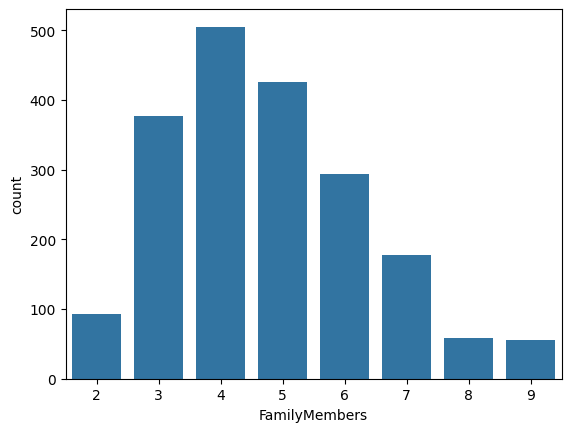

In [12]:
sns.countplot(x="FamilyMembers",data=df)

In [13]:
def family_aggregate(data):
    if data<3:
        return "small"
    if data<6:
        return "medium"
    else:
        return "big"

In [14]:
df["Family"] = df["FamilyMembers"].apply(family_aggregate)
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,Income,Family
0,31,Government Sector,Yes,400000,6,1,No,No,0,low,big
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,high,big
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,medium,medium
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,medium,medium
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,medium,big


In [15]:
def yes_no_converter(data):
    if data == 1:
        return "Yes"
    else:
        return "No"
df["ChronicDiseases"] = df["ChronicDiseases"].apply(yes_no_converter)

In [16]:
df.columns

Index(['Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome',
       'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance', 'Income', 'Family'],
      dtype='object')

In [17]:
df_new = df[['Age', 'Employment Type', 'GraduateOrNot',
    'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'TravelInsurance', 'Income', 'Family']]
df_new.head()

,Age,Employment Type,GraduateOrNot,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,Income,Family
0,31,Government Sector,Yes,Yes,No,No,0,low,big
1,31,Private Sector/Self Employed,Yes,No,No,No,0,high,big
2,34,Private Sector/Self Employed,Yes,Yes,No,No,1,medium,medium
3,28,Private Sector/Self Employed,Yes,Yes,No,No,0,medium,medium
4,28,Private Sector/Self Employed,Yes,Yes,Yes,No,0,medium,big


In [18]:
X = df[['Age', 'Employment Type', 'GraduateOrNot',
        'ChronicDiseases', 'FrequentFlyer',
       'EverTravelledAbroad', 'Income', 'Family']]
y=df["TravelInsurance"]

In [19]:
X.columns = X.columns.str.lower().str.replace(" ","_")

In [20]:
X.columns

Index(['age', 'employment_type', 'graduateornot', 'chronicdiseases',
       'frequentflyer', 'evertravelledabroad', 'income', 'family'],
      dtype='object')

In [21]:
num_col = X.select_dtypes(
    exclude=['object']
).columns

cat_col = X.select_dtypes(
    include=['object']
).columns

In [22]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler())
]
)

cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="most_frequent")),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [23]:
preprocessor = ColumnTransformer([
    ('num',num_pipeline,num_col),
    ('cat',cat_pipeline,cat_col)
])

In [24]:
X

,age,employment_type,graduateornot,chronicdiseases,frequentflyer,evertravelledabroad,income,family
0,31,Government Sector,Yes,Yes,No,No,low,big
1,31,Private Sector/Self Employed,Yes,No,No,No,high,big
2,34,Private Sector/Self Employed,Yes,Yes,No,No,medium,medium
3,28,Private Sector/Self Employed,Yes,Yes,No,No,medium,medium
4,28,Private Sector/Self Employed,Yes,Yes,Yes,No,medium,big
...,...,...,...,...,...,...,...,...
1982,33,Private Sector/Self Employed,Yes,No,Yes,Yes,very high,medium
1983,28,Private Sector/Self Employed,Yes,Yes,No,Yes,very high,medium
1984,28,Private Sector/Self Employed,Yes,Yes,No,No,high,big
1985,34,Private Sector/Self Employed,Yes,No,Yes,Yes,high,big


In [25]:
y

0       0
1       0
2       1
3       0
4       0
       ..
1982    1
1983    0
1984    0
1985    1
1986    0
Name: TravelInsurance, Length: 1987, dtype: int64

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [27]:
model_name = {
    "LogisticRegression":LogisticRegression(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "SVC":SVC(),
    "KNN":KNeighborsClassifier()
}

In [28]:
from sklearn.model_selection import cross_val_score
results = []
for name,model in model_name.items():
    pipeline = Pipeline([
        ('preprocessing',preprocessor),
        ('model',model)
    ])

    scores = cross_val_score(
             pipeline,
             X_train,
             y_train,
             cv=5
    )

    results.append(f"{name}:{scores.mean()}")

In [29]:
results

['LogisticRegression:0.7734380890026388',
 'DecisionTreeClassifier:0.7973612681784814',
 'RandomForestClassifier:0.801763783901752',
 'SVC:0.8131004106898401',
 'KNN:0.7923456937087078']

In [30]:
final_pipeline = Pipeline([
    ("preprocessing",preprocessor),
    ("model",SVC())
])

In [31]:
final_pipeline.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred =final_pipeline.predict(X_test)

In [33]:
accuracy = accuracy_score(y_pred,y_test)
accuracy

0.821608040201005

In [34]:
import joblib
joblib.dump(final_pipeline,"travel_insurance_model.pkl")

['travel_insurance_model.pkl']